# **MÓDULO 17 - Projeto de Credit Score - Parte 1 - Processamento dos dados**


Essa é a primeira etapa do processo de Credit Score que vocês desenvolverão durante nosso curso.
Nessa primeira etapa vocês irão aplicar os passos aprendidos nos módulos de pré processamento para preparar a base de vocês para o desenvolvimento do modelo.

O termo "credit score" se refere a uma pontuação numérica que representa a credibilidade de um indivíduo em termos de cumprimento de obrigações financeiras, como pagar contas de empréstimos, cartões de crédito, entre outros. Essa pontuação é calculada com base em diversas informações financeiras e de crédito do indivíduo, como histórico de pagamentos, níveis de endividamento, tempo de crédito, tipos de crédito utilizados, entre outros.

O objetivo de um modelo de credit score é prever o risco de um indivíduo se tornar inadimplente com suas obrigações financeiras. Em outras palavras, o modelo avalia a probabilidade de um indivíduo não cumprir com os pagamentos de empréstimos ou outros compromissos financeiros. Essa previsão é fundamental para instituições financeiras, como bancos e credores, na tomada de decisão sobre a concessão de crédito. Um modelo de credit score eficaz pode ajudar essas instituições a avaliar o risco de emprestar dinheiro a um determinado indivíduo e, assim, tomar decisões mais informadas sobre a aprovação ou negação de crédito, bem como sobre os termos e condições desses empréstimos.

**Atenção:** Notem que esse projeto é diferente da base que tenho trabalhado com vocês em aula, apesar de se tratar de uma base bancária durante a aula falamos sobre a variável Churn a ser prevista, nesse caso a previsão seria do valor do Score de Crédito.

In [201]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from scipy import stats
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [202]:
df = pd.read_csv(r"C:\Users\Rafael\Downloads\Cursos\Ebac\Curso de Ciencia de Dados\15 - Correlação, Balanceamento, Variáveis ​​Categóricas\CREDIT_SCORE_PROJETO_PARTE1.csv", delimiter=';')

df.head(10)

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
0,25.0,Female,"50.000,00",Bachelor's Degree,Single,0,Rented,High
1,30.0,Male,"100.000,00",Master's Degree,Married,2,Owned,High
2,35.0,Female,"75.000,00",Doctorate,Married,1,Owned,High
3,40.0,Male,"125.000,00",High School Diploma,Single,0,Owned,High
4,45.0,Female,"100.000,00",Bachelor's Degree,Married,3,Owned,High
5,50.0,Male,"150.000,00",Master's Degree,Married,0,Owned,High
6,26.0,Female,"40.000,00",Associate's Degree,Single,0,Rented,Average
7,31.0,Male,"60.000,00",Bachelor's Degree,Single,0,Rented,Average
8,NaN,Female,"80.000,00",Master's Degree,Married,2,Owned,High
9,NaN,Male,"105.000,00",Doctorate,Single,0,Owned,High


Legenda dos dados:

*   **Age** : Idade dos nossos clientes.

*   **Income** : Salário Mensal.

*   **Gender** : Gênero.

*   **Education** : Nível de escolaridade dos clientes.

*   **Marital** : Status Civilmente.

*   **Number of Children** : Quantidade de filhos.

*   **Home** : Tipo de residência, alugada ou própria.

*   **Credit Score** : Nossa variável preditora, o score de crédito dos clientes.


# Etapa 1: Relize os passos que vimos no módulo 18, de pré processamento dos dados.

**A) Verifique os tipos de dados, fazendo as transformações quando necessário.**


In [203]:
df.info()
print('\n')
espaco = '-' * 50
print(espaco)
print('\n')
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 130 non-null    float64
 1   Gender              164 non-null    object 
 2   Income              164 non-null    object 
 3   Education           164 non-null    object 
 4   Marital Status      164 non-null    object 
 5   Number of Children  164 non-null    int64  
 6   Home Ownership      164 non-null    object 
 7   Credit Score        164 non-null    object 
dtypes: float64(1), int64(1), object(6)
memory usage: 10.4+ KB


--------------------------------------------------




Age                   float64
Gender                 object
Income                 object
Education              object
Marital Status         object
Number of Children      int64
Home Ownership         object
Credit Score           object
dtype: object

In [204]:
cols = ["Age", "Income"]
total_linhas = len(df)

for col in cols:
    s_numeric = pd.to_numeric(df[col], errors="coerce")

    qtd_nulos = s_numeric.isna().sum()
    qtd_inf = np.isinf(s_numeric).sum()
    total_problemas = qtd_nulos + qtd_inf

    pct_nulos = (qtd_nulos / total_linhas) * 100
    pct_inf = (qtd_inf / total_linhas) * 100
    pct_total = (total_problemas / total_linhas) * 100

    print(f"=== Coluna: {col} ===")
    print(f"Nulos (NaN):     {qtd_nulos:6d} | {pct_nulos:6.2f}%")
    print(f"Infinitos (inf): {qtd_inf:6d} | {pct_inf:6.2f}%")
    print(f"Total Inválidos: {total_problemas:6d} | {pct_total:6.2f}%\n")

=== Coluna: Age ===
Nulos (NaN):         34 |  20.73%
Infinitos (inf):      0 |   0.00%
Total Inválidos:     34 |  20.73%

=== Coluna: Income ===
Nulos (NaN):        164 | 100.00%
Infinitos (inf):      0 |   0.00%
Total Inválidos:    164 | 100.00%



In [205]:
media_age = df["Age"].mean()
mediana_age = df["Age"].median()
print(f"Média da idade: {media_age:.2f}")
print(f"Mediana da idade: {mediana_age:.2f}")
print(df["Age"].describe())

Média da idade: 37.51
Mediana da idade: 36.00
count    130.000000
mean      37.507692
std        8.500110
min       25.000000
25%       30.000000
50%       36.000000
75%       45.000000
max       53.000000
Name: Age, dtype: float64


In [206]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Age"] = df["Age"].astype(int)
print("Nulos restantes em Age:", df["Age"].isna().sum())
print("Tipo da coluna Age:", df["Age"].dtype)

Nulos restantes em Age: 0
Tipo da coluna Age: int64


In [207]:
print(df["Income"].head(10).tolist())

['50.000,00', '100.000,00', '75.000,00', '125.000,00', '100.000,00', '150.000,00', '40.000,00', '60.000,00', '80.000,00', '105.000,00']


In [208]:
df["Income"] = (
    df["Income"]
    .astype(str)  
    .str.replace("R$", "", regex=False)  
    .str.strip()  
    .str.replace(".", "", regex=False)  
    .str.replace(",", ".", regex=False)  
)
df["Income"] = pd.to_numeric(df["Income"], errors="coerce")
print("Nulos em Income após a limpeza:", df["Income"].isna().sum())
print(df["Income"].head())

Nulos em Income após a limpeza: 0
0     50000.0
1    100000.0
2     75000.0
3    125000.0
4    100000.0
Name: Income, dtype: float64


In [209]:
df["Income"] = (
    df["Income"]
    .astype(str)
    .str.replace(".", "", regex=False) 
    .str.replace(",", ".", regex=False)  
)
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df["Income"] = pd.to_numeric(df["Income"], errors="coerce")
df = df.dropna(subset=["Age", "Income"])
df["Age"] = df["Age"].astype(int)
df["Income"] = df["Income"].astype(float)
print(df.dtypes)
print(df[["Age", "Income"]].head())

Age                     int64
Gender                 object
Income                float64
Education              object
Marital Status         object
Number of Children      int64
Home Ownership         object
Credit Score           object
dtype: object
   Age     Income
0   25   500000.0
1   30  1000000.0
2   35   750000.0
3   40  1250000.0
4   45  1000000.0


**B) Verifique se temos colunas com dados faltantes.
Caso existam colunas com dados faltantes faça o tratamento desses dados, excluindo ou substituindo esses valores. Justifique sua escolha.**

In [210]:
nulos_por_coluna = df.isna().sum()
porcentagem_nulos = (nulos_por_coluna / len(df)) * 100
resumo_nulos = pd.DataFrame(
    {
        "Qtd Nulos": nulos_por_coluna,
        "% Nulos": porcentagem_nulos.round(2),
        "Tipo": df.dtypes,
    }
)
colunas_com_nulos = resumo_nulos[resumo_nulos["Qtd Nulos"] > 0]
if len(colunas_com_nulos) > 0:
    print("⚠️ Colunas com dados faltantes encontradas:")
    print(colunas_com_nulos)
else:
    print("✅ Nenhuma coluna possui dados faltantes! O DataFrame está limpo.")

✅ Nenhuma coluna possui dados faltantes! O DataFrame está limpo.


**C) Verifique se temos valores digitados de forma incorreta nas variáveis categóricas que necessitem de tratamento.**

In [211]:
colunas_categoricas = df.select_dtypes(include=["object", "category"]).columns
print("=== VERIFICAÇÃO DE ERROS EM VARIÁVEIS CATEGÓRICAS ===\n")
if len(colunas_categoricas) == 0:
    print("Nenhuma coluna categórica encontrada no DataFrame.")
else:
    for col in colunas_categoricas:
        print(f"📌 Coluna: '{col}'")
        contagem = df[col].value_counts(dropna=False)
        print(contagem)
        print("-" * 40)

=== VERIFICAÇÃO DE ERROS EM VARIÁVEIS CATEGÓRICAS ===

📌 Coluna: 'Gender'
Gender
Female    86
Male      78
Name: count, dtype: int64
----------------------------------------
📌 Coluna: 'Education'
Education
Bachelor's Degree      42
Master's Degree        36
Doctorate              31
High School Diploma    30
Associate's Degree     25
Name: count, dtype: int64
----------------------------------------
📌 Coluna: 'Marital Status'
Marital Status
Married    87
Single     77
Name: count, dtype: int64
----------------------------------------
📌 Coluna: 'Home Ownership'
Home Ownership
Owned     111
Rented     53
Name: count, dtype: int64
----------------------------------------
📌 Coluna: 'Credit Score'
Credit Score
High       113
Average     36
Low         15
Name: count, dtype: int64
----------------------------------------


In [212]:
import pandas as pd
colunas_categoricas = df.select_dtypes(include=["object", "category"]).columns
for col in colunas_categoricas:
    valores_originais = df[col].dropna().unique()
    valores_limpos = (
        df[col].dropna().astype(str).str.strip().str.lower().unique()
    )
    if len(valores_originais) != len(valores_limpos):
        print(
            f"⚠️  Possível erro de digitação/formatação na coluna: '{col}'"
        )
        print(f"   Valores originais encontrados: {list(valores_originais)}\n")

# Etapa 2: Relize os passos que vimos no módulo 15, de análise.

**A) Realiza a análise univariada, aplique a função describe ao nosso dataframe para verificar os dados das variáveis numéricas, se encontrar a possível presença de outliers analise com gráficos a distribuição dos dados.Traga insights sobre os dados analisados.**

              Age        Income  Number of Children
count  164.000000  1.640000e+02          164.000000
mean    37.195122  8.376524e+05            0.652439
std      7.586619  3.245731e+05            0.883346
min     25.000000  2.500000e+05            0.000000
25%     31.750000  5.750000e+05            0.000000
50%     36.000000  8.375000e+05            0.000000
75%     43.000000  1.050000e+06            1.000000
max     53.000000  1.625000e+06            3.000000


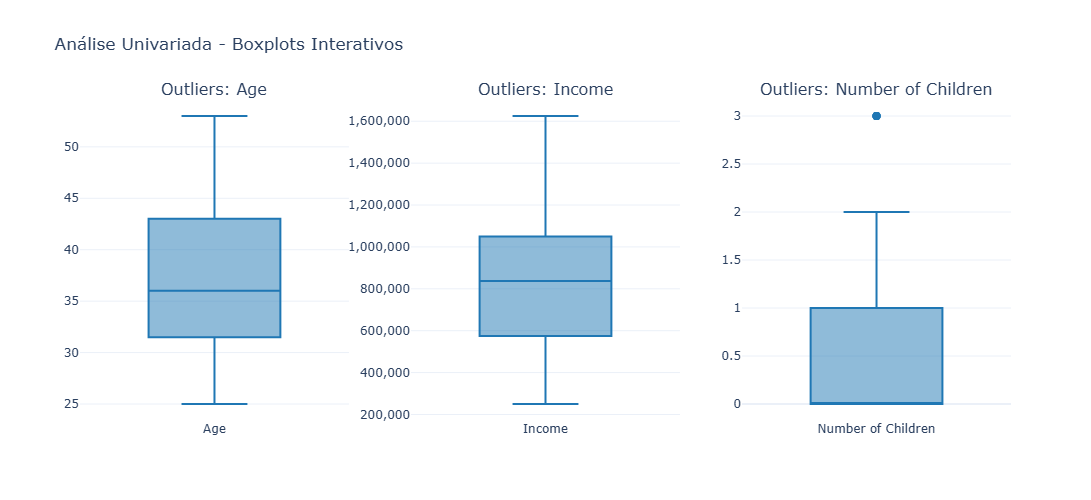

In [213]:
resumo = df.describe()
print(resumo)
colunas = ['Age', 'Income', 'Number of Children']
fig = make_subplots(
    rows=1, 
    cols=3, 
    subplot_titles=[f'Outliers: {col}' for col in colunas]
)
for i, col in enumerate(colunas, 1):
    fig.add_trace(
        go.Box(
            y=df[col],
            name=col,
            boxpoints='outliers',
            marker_color='#1f77b4',
            marker=dict(outliercolor='red', size=8)
        ),
        row=1, col=i
    )
fig.update_layout(
    showlegend=False,
    height=500,
    width=900,
    title_text="Análise Univariada - Boxplots Interativos",
    template="plotly_white"
)
fig.update_yaxes(tickformat=",.0f", row=1, col=2)
fig.show()

In [214]:
# foi encontrado apenas um outlier que está na parte coluna Number of Children que é correspondente ao numero 
# de filhos de cada cliente, mas esse numero 3 nao é nada a ter que se preocupar pois como o valor padrao é 
# de 0 a 2, 3 quer dizer que é um caso raro comparado ao padrao encontrado na analise apenas isso nada que
# vai interferir muito na analise nesse momento.

**B) Agora realize a análise univariada para as variaveis categóricas, plote gráficos para entender a distribuição das categorias e tente retirar insights de cada gráfico.**

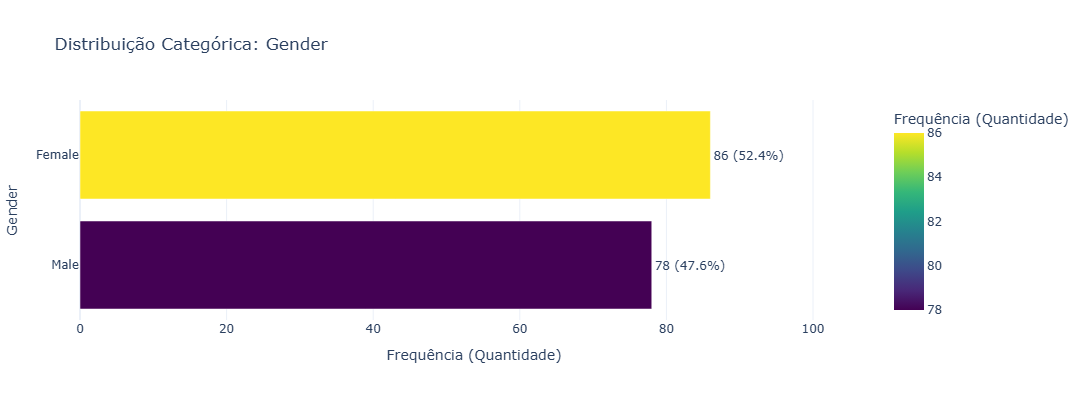

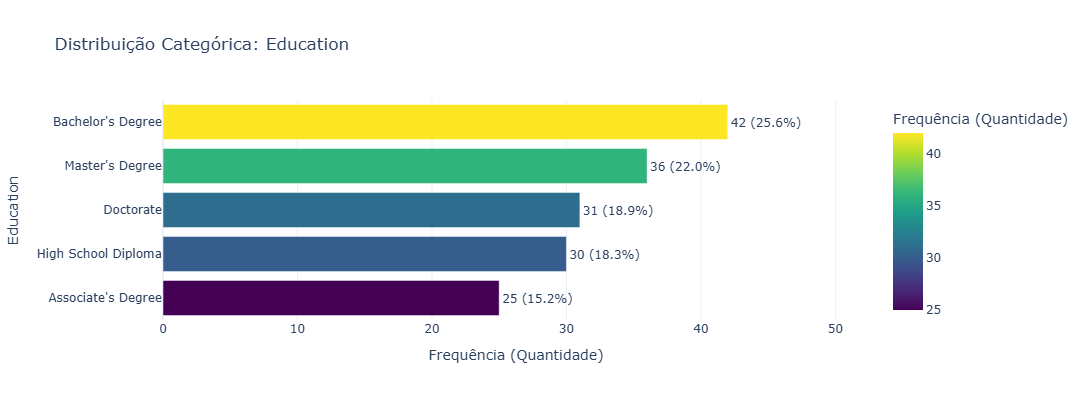

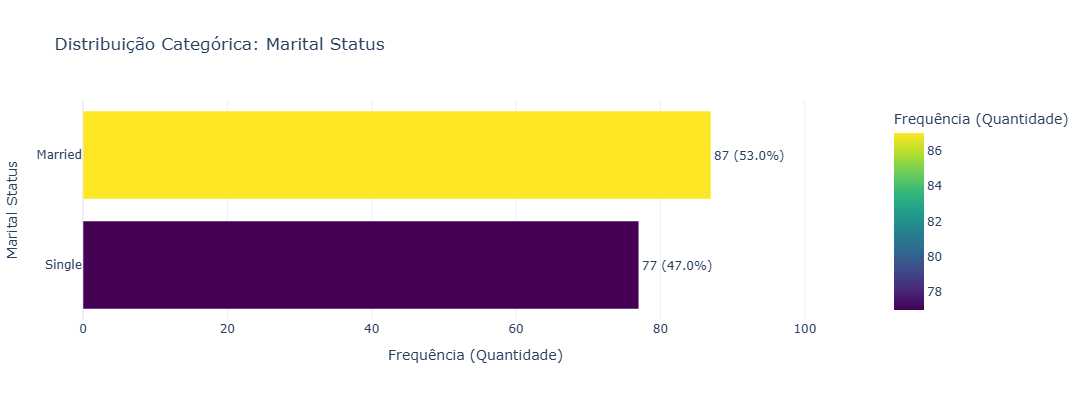

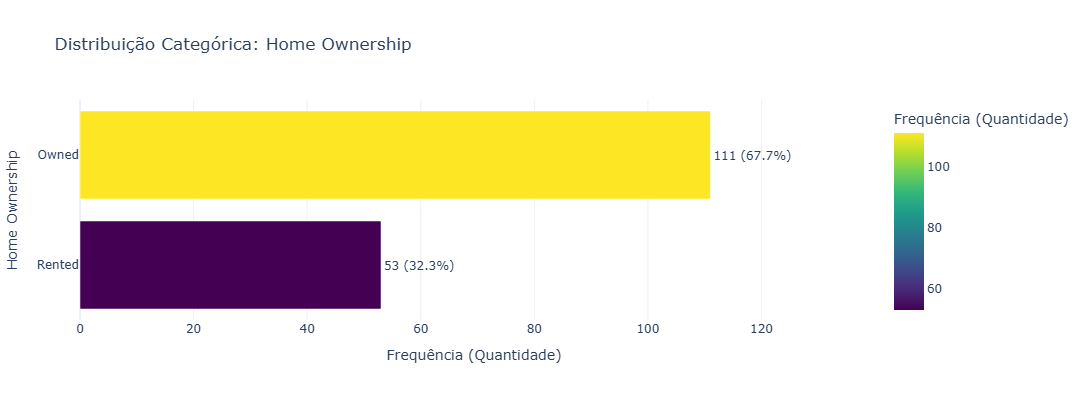

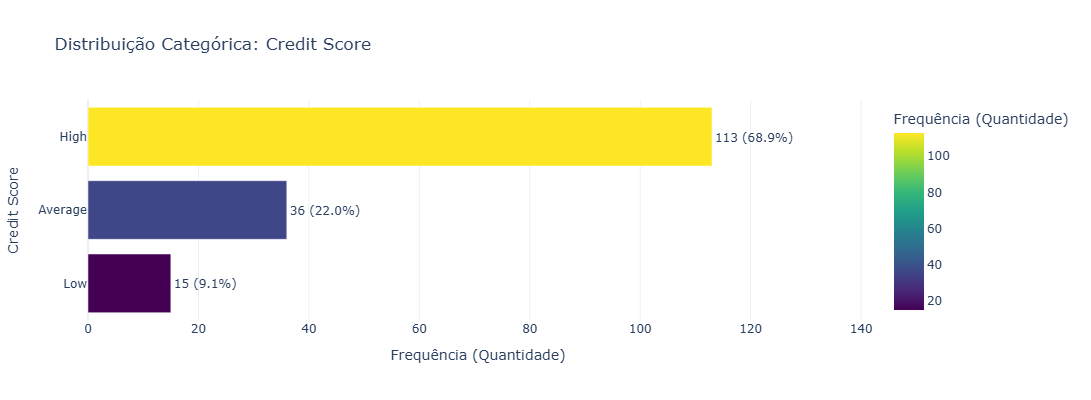

In [215]:
def plotar_barras_categoricas(df, max_categorias=15):
    colunas_categoricas = df.select_dtypes(
        include=["object", "category"]
    ).columns
    if len(colunas_categoricas) == 0:
        print("Nenhuma variável categórica foi encontrada no DataFrame.")
        return
    for col in colunas_categoricas:
        contagem = df[col].value_counts(dropna=False)
        total_linhas = len(df)
        dados_plot = contagem.head(max_categorias).reset_index()
        dados_plot.columns = [col, "Contagem"]
        dados_plot["Porcentagem"] = (
            dados_plot["Contagem"] / total_linhas
        ) * 100
        dados_plot["Rotulo"] = dados_plot.apply(
            lambda r: f"{int(r['Contagem'])} ({r['Porcentagem']:.1f}%)", axis=1
        )
        fig = px.bar(
            dados_plot,
            x="Contagem",
            y=col,
            orientation="h",
            text="Rotulo",
            color="Contagem",
            color_continuous_scale="Viridis",
            title=f"Distribuição Categórica: {col}",
            labels={"Contagem": "Frequência (Quantidade)", col: col},
            custom_data=["Porcentagem"],
        )
        fig.update_traces(
            textposition="outside",
            hovertemplate=f"<b>{col}</b>: %{{y}}<br><b>Contagem</b>: %{{x}}<br><b>Porcentagem</b>: %{{customdata[0]:.2f}}%<extra></extra>",
        )
        fig.update_layout(
            yaxis={"categoryorder": "total ascending"},
            xaxis={"range": [0, max(dados_plot["Contagem"]) * 1.25]},
            showlegend=False,
            height=400,
            template="plotly_white",
        )
        nulos = df[col].isna().sum()
        if nulos > 0:
            print(f"[Aviso] A coluna '{col}' possui {nulos} valores ausentes.")
        if df[col].nunique() > max_categorias:
            print(
                f"[Aviso] A coluna '{col}' possui {df[col].nunique()} categorias. Exibindo apenas as top {max_categorias} no gráfico."
            )
        fig.show()
plotar_barras_categoricas(df)

In [216]:
# 1 - insights Grafíco Gender: Houve uma maior prevalência do público feminino na base de clientes (52,4% contra 47,6%), estabelecendo 
# esse grupo como a principal força de consumo atual. Estratégia recomendada: priorizar o engajamento e a 
# retenção do público feminino em campanhas principais, mantendo ações direcionadas de aquisição para o
# público masculino para equalizar a base.

# 2 - insights Grafíco Education: Predominância expressiva de clientes com qualificação de nível superior e pós-graduação, englobando 66,5% do
# público analisado (liderados por Bachelor's Degree com 25,6%). Essa característica aponta para um perfil demográfico de maior escolaridade e 
# potencial econômico elevado.

# 3 -  insights Grafíco Marital Status: A base apresenta um perfil equilibrado quanto ao estado civil, com uma ligeira maioria de clientes casados
# (53,0%) frente aos solteiros (47,0%). A paridade entre os grupos permite criar estratégias de comunicação segmentadas: campanhas com apelo familiar
# ou de longo prazo para o público casado, e abordagens focadas em praticidade e individualidade para o público solteiro, sem perda de alcance em
# nenhum dos segmentos.

# 4 - insights Grafíco Home: Observa-se uma clara predominância de clientes com imóvel próprio, representando 67,7% da base (111 clientes), 
# contra 32,3% de inquilinos (53 clientes). Essa forte concentração em casa própria sugere um perfil de cliente com maior estabilidade
# financeira e menor rotatividade geográfica.

# 5 - insights Grafíco Home Forte concentração de clientes com bom perfil de crédito, onde 68,9% possuem Credit Score alto e 22,0% médio, totalizando 90,9% de clientes
# adimplentes e qualificados. Essa característica indica um público com baixo risco financeiro.

**C) Você encontrou alguma coluna com outliers?
Se sim realize o tratamento desses casos.**

-> Nenhuma coluna numérica foi especificada. Usando automaticamente: 'Age'

ESTATÍSTICAS DESCRITIVAS DE 'Age' POR 'Gender'
Gender  count      mean      std  min  25%  50%  75%  max
Female   86.0 35.720930 7.430701 25.0 29.0 36.0 39.0 49.0
  Male   78.0 38.820513 7.468972 28.0 33.0 36.0 43.0 53.0




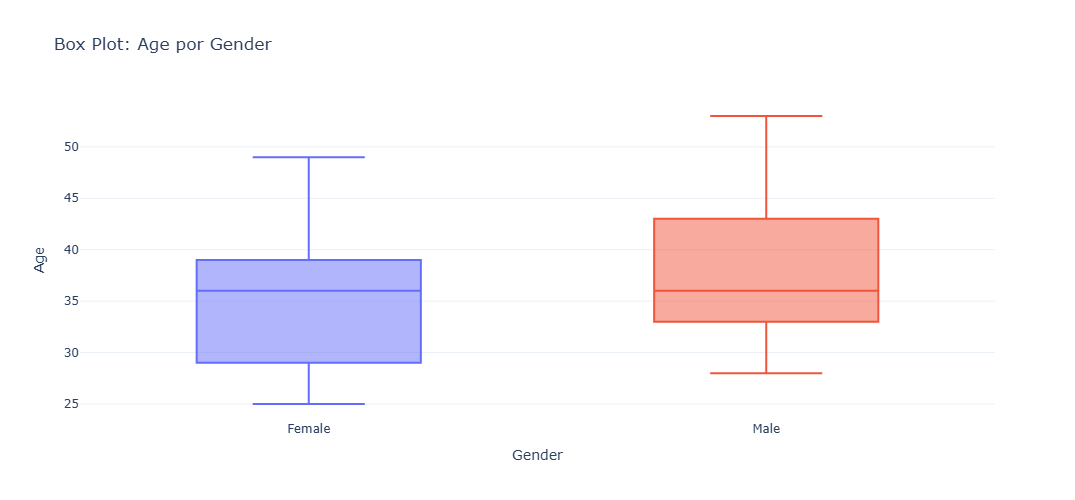

ESTATÍSTICAS DESCRITIVAS DE 'Age' POR 'Education'
          Education  count      mean      std  min   25%  50%   75%  max
 Associate's Degree   25.0 34.640000 8.966976 26.0 28.00 34.0 36.00 53.0
  Bachelor's Degree   42.0 35.476190 7.619737 25.0 31.00 36.0 39.00 51.0
          Doctorate   31.0 40.129032 6.438126 29.0 35.00 36.0 47.50 49.0
High School Diploma   30.0 37.033333 7.406816 27.0 33.00 36.0 40.00 52.0
    Master's Degree   36.0 38.583333 6.788120 30.0 32.75 36.0 43.25 50.0




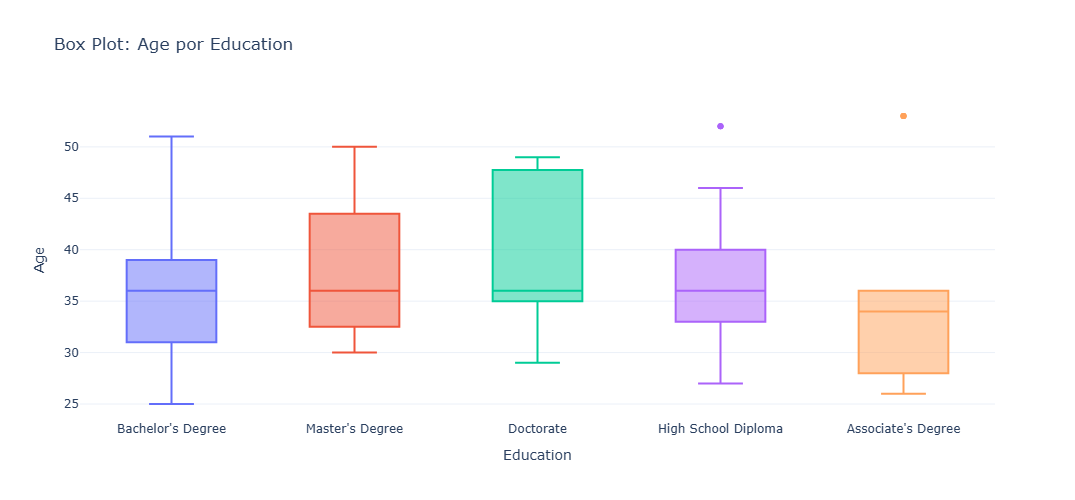

ESTATÍSTICAS DESCRITIVAS DE 'Age' POR 'Marital Status'
Marital Status  count      mean      std  min  25%  50%  75%  max
       Married   87.0 40.390805 7.416757 26.0 36.0 37.0 48.0 53.0
        Single   77.0 33.584416 6.024840 25.0 28.0 33.0 36.0 44.0




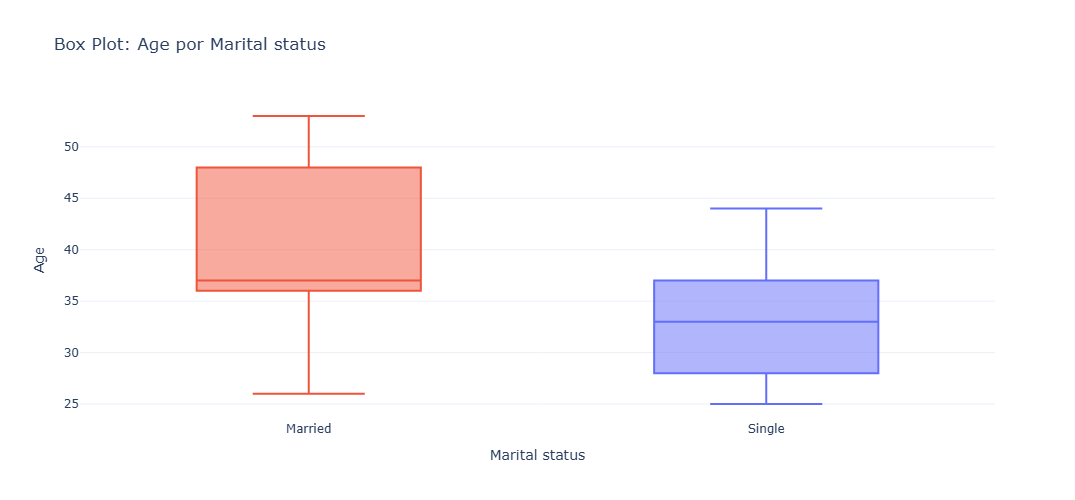

ESTATÍSTICAS DESCRITIVAS DE 'Age' POR 'Home Ownership'
Home Ownership  count      mean      std  min  25%  50%  75%  max
         Owned  111.0 40.477477 6.669942 26.0 36.0 39.0 46.0 53.0
        Rented   53.0 30.320755 3.891675 25.0 27.0 31.0 34.0 36.0




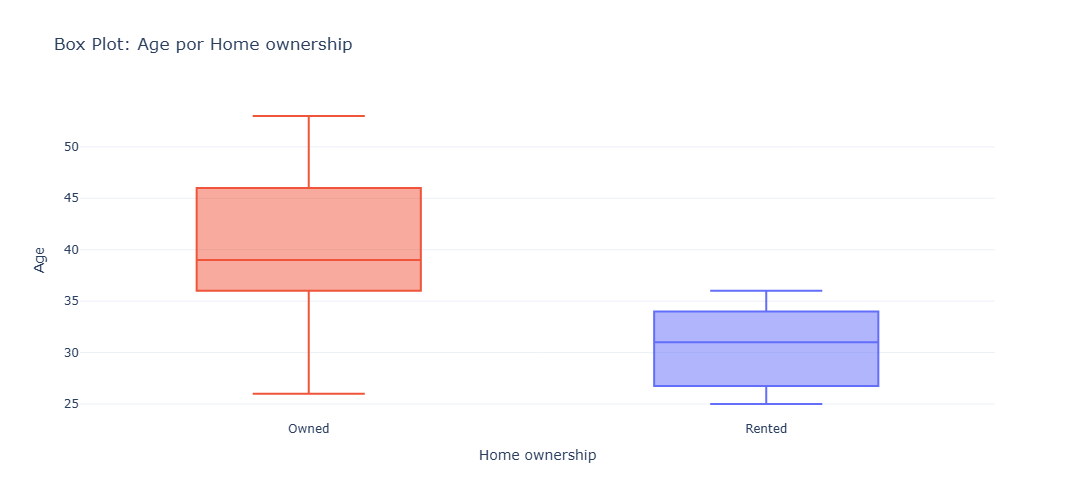

ESTATÍSTICAS DESCRITIVAS DE 'Age' POR 'Credit Score'
Credit Score  count      mean      std  min  25%  50%   75%  max
     Average   36.0 30.194444 4.041354 25.0 26.0 31.0 33.25 36.0
        High  113.0 40.353982 6.677414 25.0 36.0 39.0 46.00 53.0
         Low   15.0 30.200000 3.687818 27.0 28.0 29.0 32.50 36.0




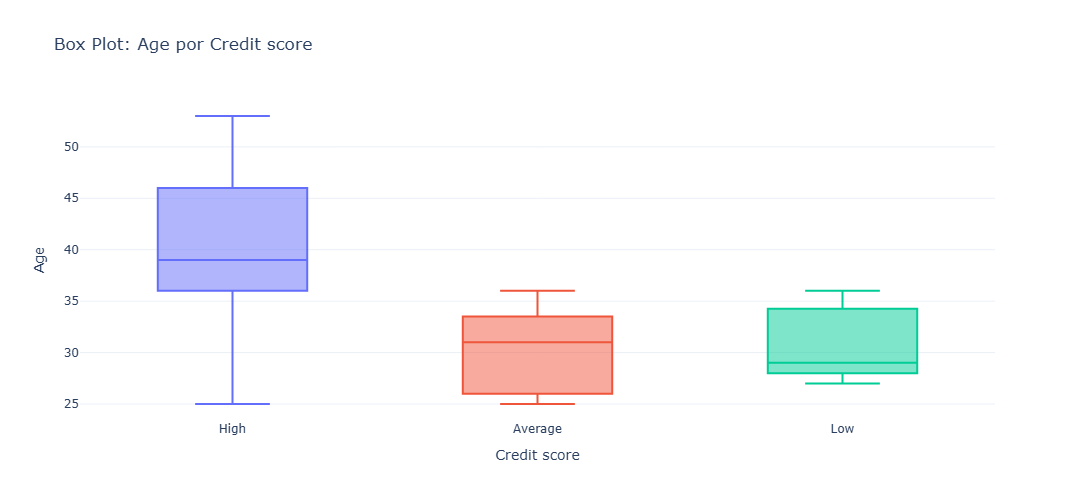

In [217]:
def analisar_outliers_categoricos(df, col_numerica=None, max_categorias=15):
    if col_numerica is None:
        cols_num = df.select_dtypes(include=["number"]).columns
        if len(cols_num) == 0:
            print("Nenhuma coluna numérica encontrada no DataFrame.")
            return
        col_numerica = cols_num[0]
        print(
            f"-> Nenhuma coluna numérica foi especificada. Usando automaticamente: '{col_numerica}'\n"
        )
    if col_numerica not in df.columns:
        print(f"Erro: A coluna '{col_numerica}' não existe no seu DataFrame.")
        print(
            f"Colunas numéricas disponíveis: {list(df.select_dtypes(include=['number']).columns)}"
        )
        return
    colunas_categoricas = df.select_dtypes(
        include=["object", "category"]
    ).columns
    if len(colunas_categoricas) == 0:
        print("Nenhuma variável categórica foi encontrada no DataFrame.")
        return
    for col in colunas_categoricas:
        print("=" * 60)
        print(f"ESTATÍSTICAS DESCRITIVAS DE '{col_numerica}' POR '{col}'")
        print("=" * 60)
        estatisticas = (
            df.groupby(col, observed=False)[col_numerica]
            .describe()
            .reset_index()
        )
        print(estatisticas.to_string(index=False))
        print("\n")
        top_categorias = (
            df[col].value_counts().head(max_categorias).index.tolist()
        )
        df_plot = df[df[col].isin(top_categorias)].copy()
        fig = px.box(
            df_plot,
            x=col,
            y=col_numerica,
            color=col,
            points="outliers",
            title=f"Box Plot: {col_numerica} por {col.capitalize()}",
            labels={
                col: col.capitalize(),
                col_numerica: col_numerica.capitalize(),
            },
            template="plotly_white",
        )
        fig.update_layout(
            showlegend=False,
            height=500,
            xaxis={"categoryorder": "total descending"},
        )
        fig.update_traces(
            hovertemplate=f"<b>{col}</b>: %{{x}}<br><b>{col_numerica}</b>: %{{y}}<extra></extra>"
        )
        nulos = df[col].isna().sum()
        if nulos > 0:
            print(f"[Aviso] A coluna '{col}' possui {nulos} valores ausentes.")

        if df[col].nunique() > max_categorias:
            print(
                f"[Aviso] A coluna '{col}' possui {df[col].nunique()} categorias. Exibindo apenas as top {max_categorias} no gráfico."
            )
        fig.show()
analisar_outliers_categoricos(df)

In [218]:
# Explicaçao do porque quis manter os outliers encontrados na variavel categoria de eduicação: Foram identificados apenas dois valores atípicos (outliers estatísticos) no cruzamento entre idade e escolaridade: um indivíduo de 52 anos na
# categoria High School Diploma e outro de 53 anos em Associate's Degree. Como ambos representam idades perfeitamente plausíveis e não consistem
# em erros de entrada de dados, os registros foram mantidos na base para preservar a integridade da amostragem.

**D) Realize a análise Bivariada.
Tente responder as seguintes perguntas com gráficos seguidos de insights:**



*   Existe relação entre a idade e o status civil?
*   Qual a relação entre o score de crédito e o nível de escolaridade?
*  O salário parece influenciar na idade?
* O salário parece influenciar no Score de Crédito?
* Clientes com casa própria tendem a ter um score mais alto?



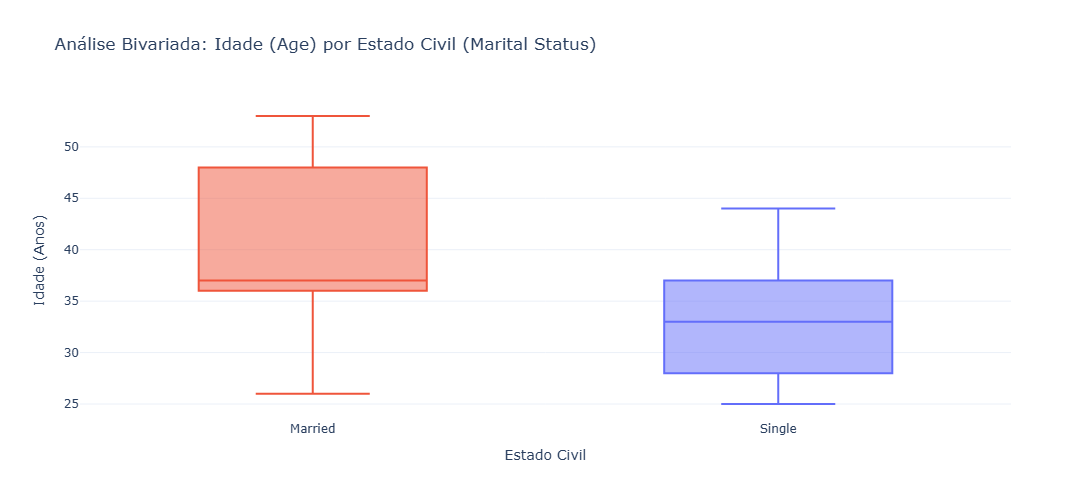


DIAGNÓSTICO AUTOMÁTICO DE ASSOCIAÇÃO (Age x Marital Status)
• Mediana de Idade (Married): 37.0 anos
• Mediana de Idade (Single):  33.0 anos
• P-Valor do Teste Estatístico: 0.0000
-----------------------------------------------------------------
RESULTADO: Existe uma associação/diferença estatisticamente significativa!
INTERPRETAÇÃO: O grupo de clientes 'Married' é significativamente mais velho que o grupo 'Single'.


In [219]:
fig = px.box(
    df,
    x="Marital Status",
    y="Age",
    color="Marital Status",
    points="outliers",
    title="Análise Bivariada: Idade (Age) por Estado Civil (Marital Status)",
    labels={"Marital Status": "Estado Civil", "Age": "Idade (Anos)"},
    template="plotly_white",
)
fig.update_layout(
    showlegend=False,
    height=500,
    xaxis={"categoryorder": "total descending"},
)
fig.update_traces(
    hovertemplate="<b>Estado Civil:</b> %{x}<br><b>Idade:</b> %{y} anos<extra></extra>"
)

fig.show()
mediana_married = df[df["Marital Status"] == "Married"]["Age"].median()
mediana_single = df[df["Marital Status"] == "Single"]["Age"].median()
grupo_married = df[df["Marital Status"] == "Married"]["Age"].dropna()
grupo_single = df[df["Marital Status"] == "Single"]["Age"].dropna()
stat, p_valor = stats.ttest_ind(grupo_married, grupo_single)
print("\n" + "=" * 65)
print("DIAGNÓSTICO AUTOMÁTICO DE ASSOCIAÇÃO (Age x Marital Status)")
print("=" * 65)
print(f"• Mediana de Idade (Married): {mediana_married:.1f} anos")
print(f"• Mediana de Idade (Single):  {mediana_single:.1f} anos")
print(f"• P-Valor do Teste Estatístico: {p_valor:.4f}")
print("-" * 65)
if p_valor <= 0.05:
    print(
        "RESULTADO: Existe uma associação/diferença estatisticamente significativa!"
    )
    if mediana_married > mediana_single:
        print(
            "INTERPRETAÇÃO: O grupo de clientes 'Married' é significativamente mais velho que o grupo 'Single'."
        )
    else:
        print(
            "INTERPRETAÇÃO: O grupo de clientes 'Single' é significativamente mais velho que o grupo 'Married'."
        )
else:
    print(
        "RESULTADO: NÃO existe diferença estatisticamente significativa de idade entre os grupos."
    )
    print(
        "INTERPRETAÇÃO: A variação de idade observada entre casados e solteiros pode ser mero acaso da amostra."
    )
print("=" * 65)

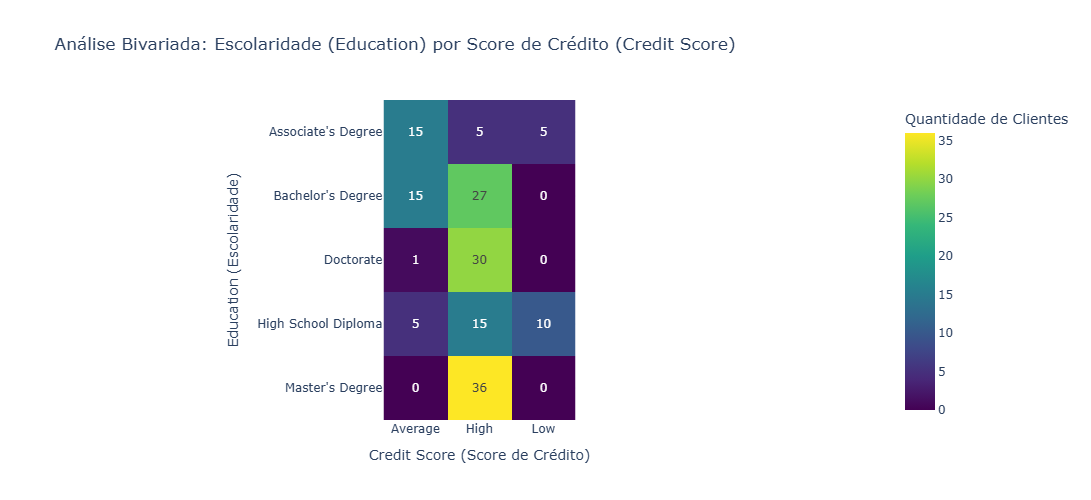


DIAGNÓSTICO AUTOMÁTICO DE ASSOCIAÇÃO (Education x Credit Score)
• P-Valor do Teste Chi-Quadrado: 0.0000
• Intensidade da Associação (V de Cramér): 0.508
-----------------------------------------------------------------
RESULTADO: Existe uma associação estatisticamente significativa entre as variáveis!
INTERPRETAÇÃO: O nível de escolaridade (Education) influencia o perfil do Score de Crédito (Credit Score) com uma intensidade FORTE.


In [220]:
tabela_cruzada = pd.crosstab(df["Education"], df["Credit Score"])
fig = px.imshow(
    tabela_cruzada,
    text_auto=True, 
    color_continuous_scale="Viridis",
    title="Análise Bivariada: Escolaridade (Education) por Score de Crédito (Credit Score)",
    labels=dict(
        x="Credit Score (Score de Crédito)",
        y="Education (Escolaridade)",
        color="Quantidade de Clientes",
    ),
    template="plotly_white",
)
fig.update_layout(height=500)
fig.show()
chi2, p_valor, dof, expected = stats.chi2_contingency(tabela_cruzada)
n = tabela_cruzada.sum().sum()
min_dim = min(tabela_cruzada.shape) - 1
cramer_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0
print("\n" + "=" * 65)
print("DIAGNÓSTICO AUTOMÁTICO DE ASSOCIAÇÃO (Education x Credit Score)")
print("=" * 65)
print(f"• P-Valor do Teste Chi-Quadrado: {p_valor:.4f}")
print(f"• Intensidade da Associação (V de Cramér): {cramer_v:.3f}")
print("-" * 65)
if p_valor <= 0.05:
    if cramer_v > 0.5:
        forca = "Forte"
    elif cramer_v > 0.3:
        forca = "Moderada"
    else:
        forca = "Fraca"
    print(
        "RESULTADO: Existe uma associação estatisticamente significativa entre as variáveis!"
    )
    print(
        f"INTERPRETAÇÃO: O nível de escolaridade (Education) influencia o perfil do Score de Crédito (Credit Score) com uma intensidade {forca.upper()}."
    )
else:
    print(
        "RESULTADO: NÃO existe associação estatisticamente significativa entre as variáveis."
    )
    print(
        "INTERPRETAÇÃO: A distribuição do Score de Crédito é independente do nível de escolaridade nesta base de dados (as variações ocorrem por mero acaso da amostra)."
    )
print("=" * 65)

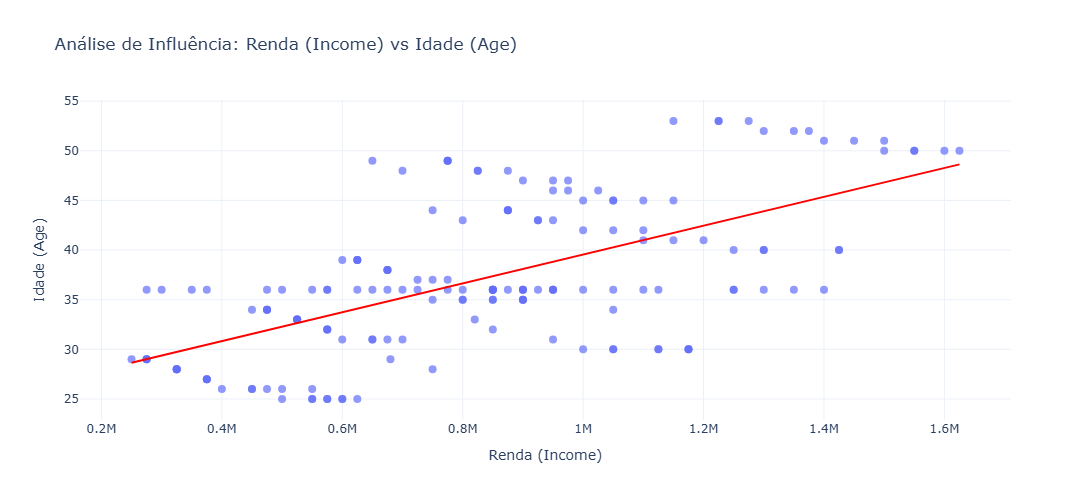


DIAGNÓSTICO AUTOMÁTICO DE INFLUÊNCIA (Income x Age)
• Coeficiente de Correlação (r): 0.6215
• Coeficiente de Determinação (R²): 0.3863 (38.6%)
• P-Valor da Relação: 6.7014e-19
-----------------------------------------------------------------
RESULTADO: Existe uma relação estatisticamente significativa entre Renda e Idade!
INTERPRETAÇÃO: A correlação é POSITIVA e de intensidade MODERADA (r = 0.62).
• Tendência: Clientes com maior Renda tendem a apresentar idades mais avançadas.
• R² (38.6%): Indica o quanto a variação da Renda explica a variação da Idade na base.


In [221]:
df_clean = df.dropna(subset=["Income", "Age"])
fig = px.scatter(
    df_clean,
    x="Income",  
    y="Age",  
    trendline="ols",  
    trendline_color_override="red",  
    title="Análise de Influência: Renda (Income) vs Idade (Age)",
    labels={"Income": "Renda (Income)", "Age": "Idade (Age)"},
    template="plotly_white",
)
fig.update_layout(height=500)
fig.update_traces(
    marker=dict(size=8, opacity=0.7),
    hovertemplate="<b>Renda:</b> $%{x:,.2f}<br><b>Idade:</b> %{y} anos<extra></extra>",
)
fig.show()
r, p_valor = stats.pearsonr(df_clean["Income"], df_clean["Age"])
r_quadrado = r**2
print("\n" + "=" * 65)
print("DIAGNÓSTICO AUTOMÁTICO DE INFLUÊNCIA (Income x Age)")
print("=" * 65)
print(f"• Coeficiente de Correlação (r): {r:.4f}")
print(f"• Coeficiente de Determinação (R²): {r_quadrado:.4f} ({r_quadrado*100:.1f}%)")
print(f"• P-Valor da Relação: {p_valor:.4e}")
print("-" * 65)
r_abs = abs(r)
if r_abs >= 0.7:
    forca = "Forte"
elif r_abs >= 0.4:
    forca = "Moderada"
elif r_abs >= 0.2:
    forca = "Fraca"
else:
    forca = "Muito Fraca / Inexistente"
direcao = "POSITIVA" if r > 0 else "NEGATIVA"
if p_valor <= 0.05:
    print(
        f"RESULTADO: Existe uma relação estatisticamente significativa entre Renda e Idade!"
    )
    print(
        f"INTERPRETAÇÃO: A correlação é {direcao} e de intensidade {forca.upper()} (r = {r:.2f})."
    )
    if r > 0:
        print(
            "• Tendência: Clientes com maior Renda tendem a apresentar idades mais avançadas."
        )
    else:
        print(
            "• Tendência: Clientes com maior Renda tendem a apresentar idades menores."
        )
    print(
        f"• R² ({r_quadrado*100:.1f}%): Indica o quanto a variação da Renda explica a variação da Idade na base."
    )
else:
    print(
        "RESULTADO: NÃO existe influência ou relação estatisticamente significativa entre as variáveis."
    )
    print(
        "INTERPRETAÇÃO: A Renda não é um fator preditivo para a Idade do cliente nesta base de dados."
    )
print("=" * 65)

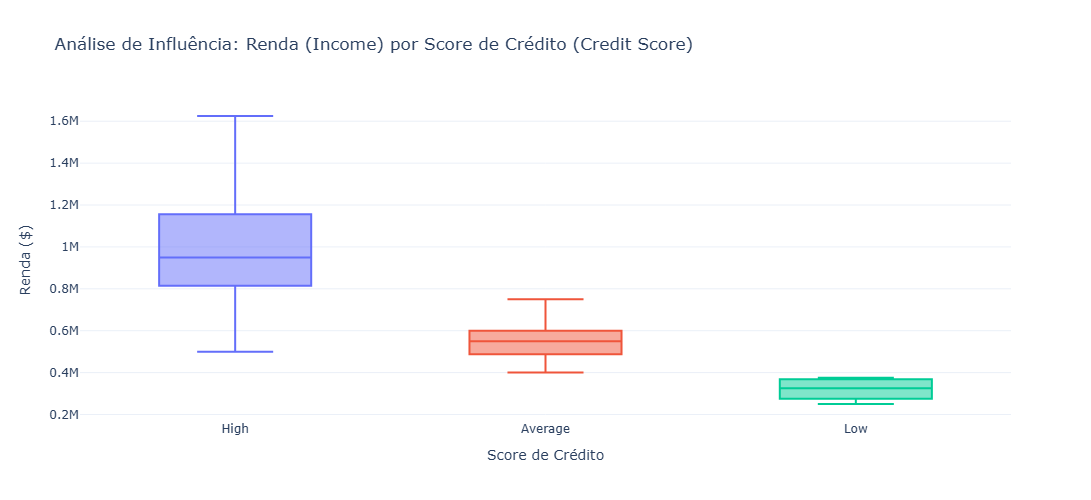


DIAGNÓSTICO AUTOMÁTICO DE INFLUÊNCIA (Income -> Credit Score)
• Teste Estatístico Utilizado: ANOVA (F-Test)
• Estatística F: 105.6002
• P-Valor: 5.0344e-30
-----------------------------------------------------------------
RESULTADO: A Renda (Income) INFLUENCIA significativamente o Credit Score!
INTERPRETAÇÃO: Existe uma diferença estatisticamente relevante nos níveis de renda entre as faixas de crédito.

Mediana de Renda por Categoria:
  • High: $950,000.00
  • Average: $550,000.00
  • Low: $325,000.00


In [222]:
df_clean = df.dropna(subset=["Credit Score", "Income"]).copy()
fig = px.box(
    df_clean,
    x="Credit Score", 
    y="Income",  
    color="Credit Score",
    points="outliers",
    title="Análise de Influência: Renda (Income) por Score de Crédito (Credit Score)",
    labels={"Credit Score": "Score de Crédito", "Income": "Renda ($)"},
    template="plotly_white",
)
fig.update_layout(
    showlegend=False,
    height=500,
    xaxis={"categoryorder": "total descending"},  
)
fig.update_traces(
    hovertemplate="<b>Credit Score:</b> %{x}<br><b>Renda:</b> $%{y:,.2f}<extra></extra>"
)
fig.show()
grupos_renda = [
    grupo["Income"].values
    for _, grupo in df_clean.groupby("Credit Score")
]
f_stat, p_valor = stats.f_oneway(*grupos_renda)
print("\n" + "=" * 65)
print("DIAGNÓSTICO AUTOMÁTICO DE INFLUÊNCIA (Income -> Credit Score)")
print("=" * 65)
print(f"• Teste Estatístico Utilizado: ANOVA (F-Test)")
print(f"• Estatística F: {f_stat:.4f}")
print(f"• P-Valor: {p_valor:.4e}")
print("-" * 65)
medianas = (
    df_clean.groupby("Credit Score")["Income"]
    .median()
    .sort_values(ascending=False)
)
if p_valor <= 0.05:
    print(
        "RESULTADO: A Renda (Income) INFLUENCIA significativamente o Credit Score!"
    )
    print(
        "INTERPRETAÇÃO: Existe uma diferença estatisticamente relevante nos níveis de renda entre as faixas de crédito."
    )
    print("\nMediana de Renda por Categoria:")
    for cat, med in medianas.items():
        print(f"  • {cat}: ${med:,.2f}")
else:
    print(
        "RESULTADO: NÃO há evidência estatística de que a Renda influencie o Credit Score."
    )
    print(
        "INTERPRETAÇÃO: A distribuição de renda é semelhante entre as categorias de crédito nesta base de dados."
    )
print("=" * 65)

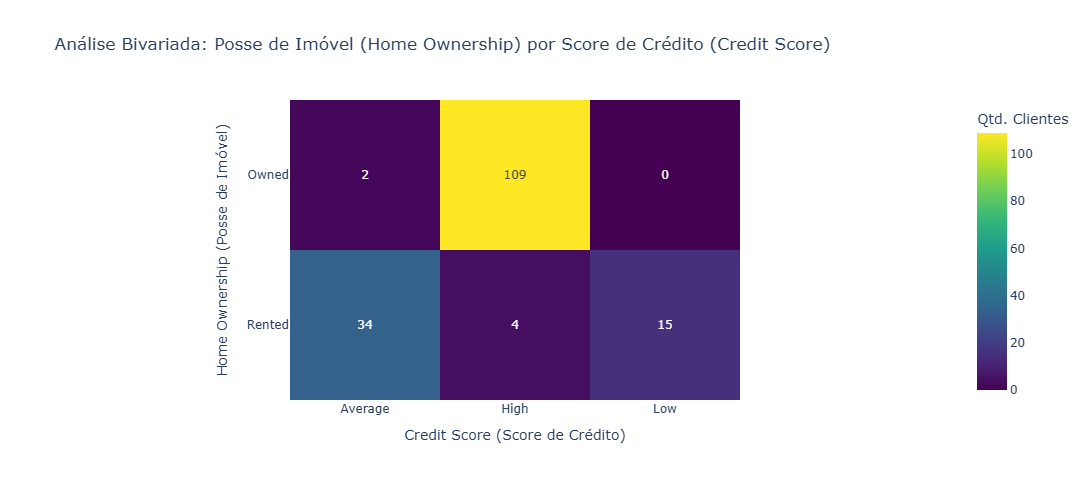


DIAGNÓSTICO AUTOMÁTICO DE ASSOCIAÇÃO (Home Ownership x Credit Score)
• P-Valor (Chi-Quadrado): 0.0000
• Intensidade da Associação (V de Cramér): 0.916
-----------------------------------------------------------------
RESULTADO: Existe uma associação estatisticamente significativa entre as variáveis!
INTERPRETAÇÃO: O tipo de moradia (Home Ownership) afeta a distribuição do Credit Score (Intensidade: FORTE).
• Destaque: Clientes na categoria 'Owned' possuem a maior concentração de Score 'High' (98.2%).


In [223]:
df_clean = df.dropna(subset=["Home Ownership", "Credit Score"]).copy()
tabela_cruzada = pd.crosstab(df_clean["Home Ownership"], df_clean["Credit Score"])
fig = px.imshow(
    tabela_cruzada,
    text_auto=True, 
    color_continuous_scale="Viridis",
    title="Análise Bivariada: Posse de Imóvel (Home Ownership) por Score de Crédito (Credit Score)",
    labels=dict(
        x="Credit Score (Score de Crédito)",
        y="Home Ownership (Posse de Imóvel)",
        color="Qtd. Clientes",
    ),
    template="plotly_white",
)
fig.update_layout(height=480)
fig.show()
chi2, p_valor, dof, expected = stats.chi2_contingency(tabela_cruzada)
n_total = tabela_cruzada.sum().sum()
min_dim = min(tabela_cruzada.shape) - 1
cramer_v = np.sqrt(chi2 / (n_total * min_dim)) if min_dim > 0 else 0
tabela_prop = pd.crosstab(
    df_clean["Home Ownership"], df_clean["Credit Score"], normalize="index"
) * 100
print("\n" + "=" * 65)
print("DIAGNÓSTICO AUTOMÁTICO DE ASSOCIAÇÃO (Home Ownership x Credit Score)")
print("=" * 65)
print(f"• P-Valor (Chi-Quadrado): {p_valor:.4f}")
print(f"• Intensidade da Associação (V de Cramér): {cramer_v:.3f}")
print("-" * 65)
if p_valor <= 0.05:
    if cramer_v > 0.5:
        forca = "Forte"
    elif cramer_v > 0.3:
        forca = "Moderada"
    else:
        forca = "Fraca"
    print(
        "RESULTADO: Existe uma associação estatisticamente significativa entre as variáveis!"
    )
    print(
        f"INTERPRETAÇÃO: O tipo de moradia (Home Ownership) afeta a distribuição do Credit Score (Intensidade: {forca.upper()})."
    )
    if "High" in tabela_prop.columns:
        categoria_top = tabela_prop["High"].idxmax()
        perc_top = tabela_prop["High"].max()
        print(
            f"• Destaque: Clientes na categoria '{categoria_top}' possuem a maior concentração de Score 'High' ({perc_top:.1f}%)."
        )
else:
    print(
        "RESULTADO: NÃO existe associação estatisticamente significativa entre as variáveis."
    )
    print(
        "INTERPRETAÇÃO: O tipo de moradia não demonstra impacto relevante sobre o Score de Crédito nesta amostra."
    )
print("=" * 65)

**E) Que outras perguntas te parecem fazer sentido explorarmos a resposta para conhecermos mais nossa base de dados e o comportamento dos clientes?**

 Elabore mais 3 perguntas e responda utilizando gráficos + insights.

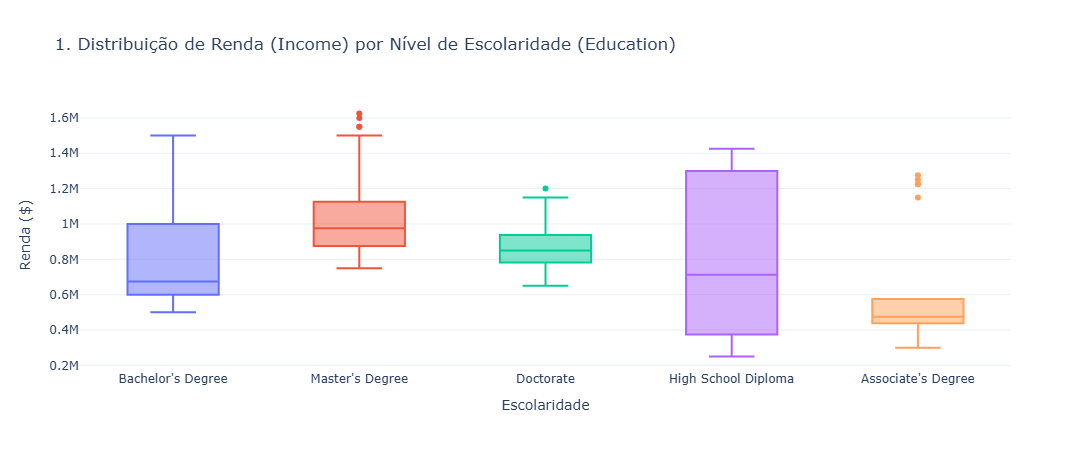

INSIGHT AUTOMÁTICO - PERGUNTA 1
• P-Valor (ANOVA): 2.1438e-06
• INSIGHT: O nível de escolaridade possui impacto estatisticamente significativo na renda.
• APLICAÇÃO DE NEGÓCIO: Clientes com pós-graduação/mestrado/doutorado podem ser alvo de produtos financeiros de maior ticket.


In [224]:
df_clean = df.dropna(subset=["Education", "Income"]).copy()

# 1. Gráfico Box Plot
fig1 = px.box(
    df_clean,
    x="Education",
    y="Income",
    color="Education",
    points="outliers",
    title="1. Distribuição de Renda (Income) por Nível de Escolaridade (Education)",
    labels={"Education": "Escolaridade", "Income": "Renda ($)"},
    template="plotly_white",
)
fig1.update_layout(showlegend=False, height=450)
fig1.show()

# 2. Teste Estatístico (ANOVA)
grupos = [
    grupo["Income"].values for _, grupo in df_clean.groupby("Education")
]
f_stat, p_valor = stats.f_oneway(*grupos)

print("=" * 65)
print("INSIGHT AUTOMÁTICO - PERGUNTA 1")
print("=" * 65)
print(f"• P-Valor (ANOVA): {p_valor:.4e}")
if p_valor <= 0.05:
    print(
        "• INSIGHT: O nível de escolaridade possui impacto estatisticamente significativo na renda."
    )
    print(
        "• APLICAÇÃO DE NEGÓCIO: Clientes com pós-graduação/mestrado/doutorado podem ser alvo de produtos financeiros de maior ticket."
    )
else:
    print(
        "• INSIGHT: Não foi identificada diferença significativa de renda entre os níveis educacionais na amostra."
    )
print("=" * 65)

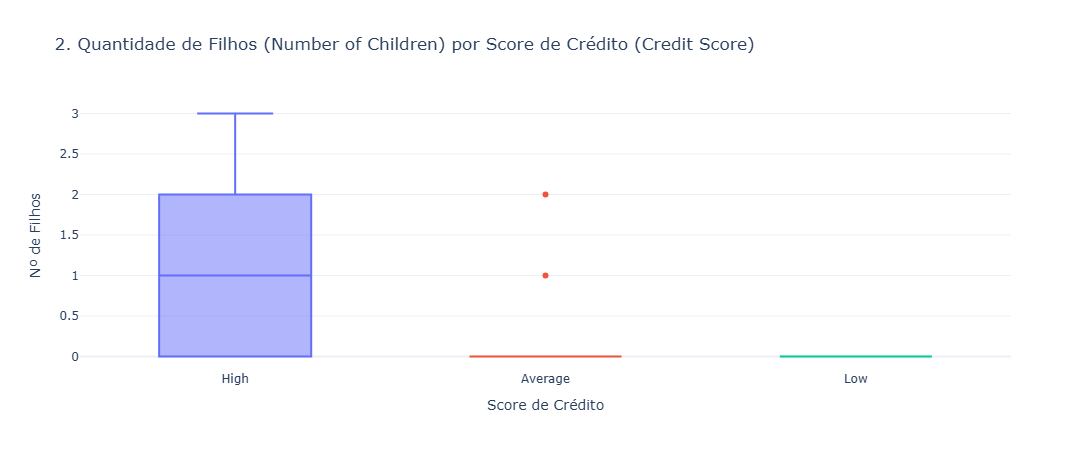

INSIGHT AUTOMÁTICO - PERGUNTA 2
• P-Valor: 0.0000
• INSIGHT: O número de dependentes/filhos afeta significativamente a categoria do Score de Crédito.
• APLICAÇÃO DE NEGÓCIO: Famílias maiores podem exigir produtos com condições de pagamento mais flexíveis ou orçamentos mais apertados.


In [225]:
df_clean = df.dropna(subset=["Credit Score", "Number of Children"]).copy()
fig2 = px.box(
    df_clean,
    x="Credit Score",
    y="Number of Children",
    color="Credit Score",
    title="2. Quantidade de Filhos (Number of Children) por Score de Crédito (Credit Score)",
    labels={
        "Credit Score": "Score de Crédito",
        "Number of Children": "Nº de Filhos",
    },
    template="plotly_white",
)
fig2.update_layout(showlegend=False, height=450)
fig2.show()
grupos = [
    g["Number of Children"].values for _, g in df_clean.groupby("Credit Score")
]
f_stat, p_valor = stats.f_oneway(*grupos)
print("=" * 65)
print("INSIGHT AUTOMÁTICO - PERGUNTA 2")
print("=" * 65)
print(f"• P-Valor: {p_valor:.4f}")
if p_valor <= 0.05:
    print(
        "• INSIGHT: O número de dependentes/filhos afeta significativamente a categoria do Score de Crédito."
    )
    print(
        "• APLICAÇÃO DE NEGÓCIO: Famílias maiores podem exigir produtos com condições de pagamento mais flexíveis ou orçamentos mais apertados."
    )
else:
    print(
        "• INSIGHT: Ter mais filhos não altera significativamente a distribuição do Score de Crédito."
    )
print("=" * 65)

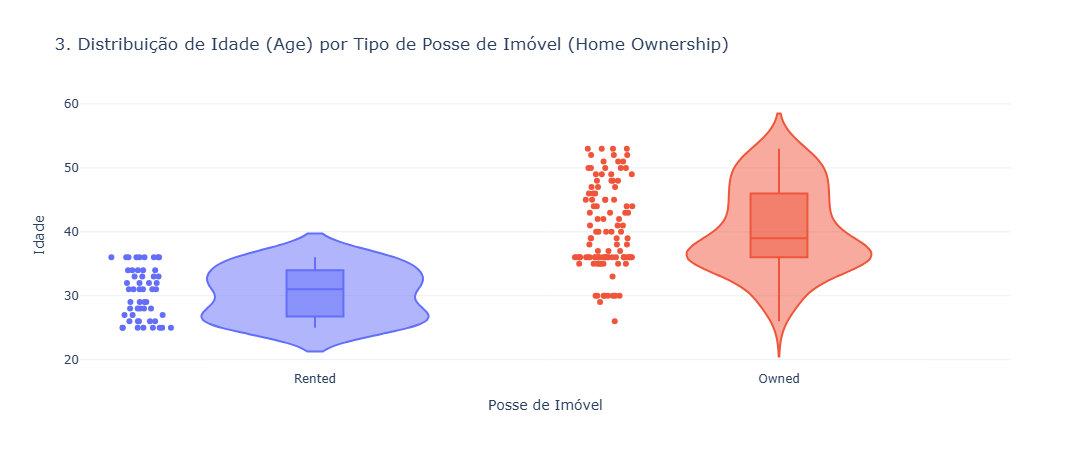

INSIGHT AUTOMÁTICO - PERGUNTA 3
• P-Valor: 0.0000
• INSIGHT: Clientes proprietários de imóveis pertencem a uma faixa etária estatisticamente diferente dos demais.
• APLICAÇÃO DE NEGÓCIO: Campanhas de financiamento imobiliário devem ser direcionadas a faixas etárias específicas com base na mediana observada.


In [226]:
df_clean = df.dropna(subset=["Home Ownership", "Age"]).copy()
fig3 = px.violin(
    df_clean,
    x="Home Ownership",
    y="Age",
    color="Home Ownership",
    box=True, 
    points="all",
    title="3. Distribuição de Idade (Age) por Tipo de Posse de Imóvel (Home Ownership)",
    labels={"Home Ownership": "Posse de Imóvel", "Age": "Idade"},
    template="plotly_white",
)
fig3.update_layout(showlegend=False, height=450)
fig3.show()
grupos = [g["Age"].values for _, g in df_clean.groupby("Home Ownership")]
f_stat, p_valor = stats.f_oneway(*grupos)
print("=" * 65)
print("INSIGHT AUTOMÁTICO - PERGUNTA 3")
print("=" * 65)
print(f"• P-Valor: {p_valor:.4f}")
if p_valor <= 0.05:
    print(
        "• INSIGHT: Clientes proprietários de imóveis pertencem a uma faixa etária estatisticamente diferente dos demais."
    )
    print(
        "• APLICAÇÃO DE NEGÓCIO: Campanhas de financiamento imobiliário devem ser direcionadas a faixas etárias específicas com base na mediana observada."
    )
else:
    print(
        "• INSIGHT: A idade não é um fator determinante isolado para a aquisição de imóvel próprio nesta base."
    )
print("=" * 65)

# Etapa 3: Relize os passos que vimos no módulo 17, de Correlação, Balanceamento, atributos categóricos e divisão base treino e teste.

**A) Vamos começar pela análise de correlação, plote da forma que achar melhor a análise de correlação, seja pela tabela ou pelo gráfico da matriz.**

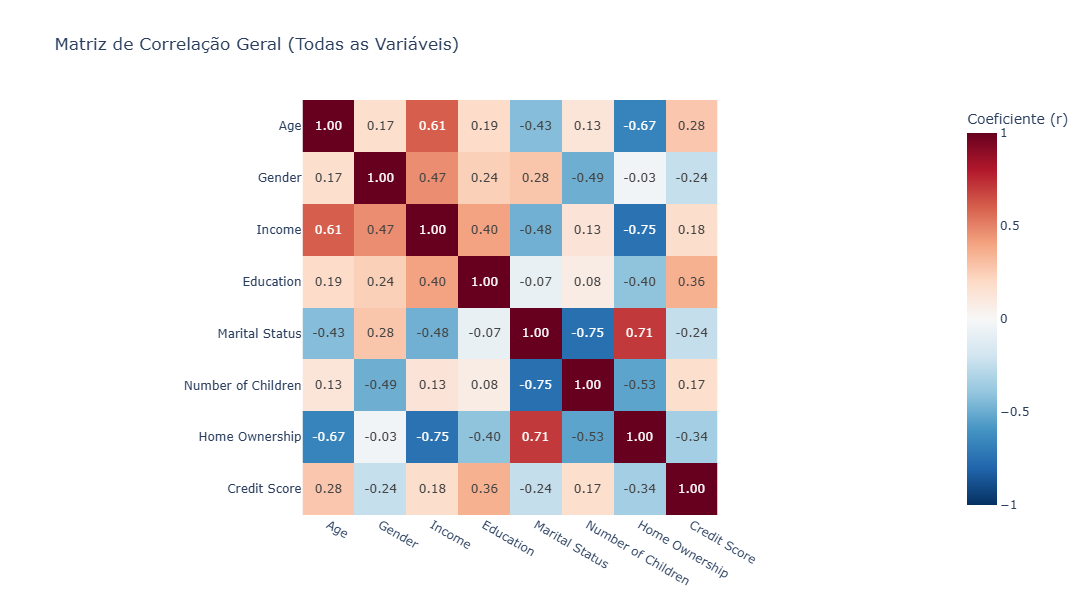


TABELA DA MATRIZ DE CORRELAÇÃO DE SPEARMAN


,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
Age,1.00,0.17,0.61,0.19,-0.43,0.13,-0.67,0.28
Gender,0.17,1.00,0.47,0.24,0.28,-0.49,-0.03,-0.24
Income,0.61,0.47,1.00,0.40,-0.48,0.13,-0.75,0.18
Education,0.19,0.24,0.40,1.00,-0.07,0.08,-0.40,0.36
Marital Status,-0.43,0.28,-0.48,-0.07,1.00,-0.75,0.71,-0.24
Number of Children,0.13,-0.49,0.13,0.08,-0.75,1.00,-0.53,0.17
Home Ownership,-0.67,-0.03,-0.75,-0.40,0.71,-0.53,1.00,-0.34
Credit Score,0.28,-0.24,0.18,0.36,-0.24,0.17,-0.34,1.00


In [227]:
colunas_alvo = [
    "Age",
    "Gender",
    "Income",
    "Education",
    "Marital Status",
    "Number of Children",
    "Home Ownership",
    "Credit Score",
]
df_alvo = df[colunas_alvo].copy()
df_encoded = df_alvo.copy()
for col in df_encoded.select_dtypes(include=["object", "category"]).columns:
    df_encoded[col] = df_encoded[col].astype("category").cat.codes
matriz_corr = df_encoded.corr(method="spearman")
fig = px.imshow(
    matriz_corr,
    text_auto=".2f",  
    color_continuous_scale="RdBu_r",  
    zmin=-1,
    zmax=1,
    title="Matriz de Correlação Geral (Todas as Variáveis)",
    labels=dict(color="Coeficiente (r)"),
    template="plotly_white",
)
fig.update_layout(height=600, width=750)
fig.show()
print("\n" + "=" * 60)
print("TABELA DA MATRIZ DE CORRELAÇÃO DE SPEARMAN")
print("=" * 60)
display(matriz_corr.round(2))

**B) Você encontrou variáveis que tem uma média ou alta correlação? Se sim, quais? Te parece fazer sentido essas variáveis terem alta correlação? Justifique.**

In [228]:
# 1 - A primeira forte correlação identificada foi entre as variáveis Income (Renda) e Home Ownership
# (Posse de Imóvel), apresentando um coeficiente de -0.75, o que classifica a relação como 
# negativamente forte.

# Apesar da forte correlação entre renda e moradia, a análise de dados deve considerar
# que correlação indica tendência de grupo, não uma regra individual. Nem todo cliente
# de renda alta busca a aquisição do imóvel próprio (podendo optar por aluguel e 
# investimentos líquidos).

# 2 - A segunda forte correlação negativa identificada foi entre as variáveis Marital Status
# (Estado Civil) e Number of Children (Número de Filhos), apresentando um coeficiente de -0.75.

# Há uma forte relação entre as duas colunas. Os dados mostram que os clientes casados 
# concentram a maioria dos filhos, enquanto os solteiros possuem poucos ou nenhum dependente,
# gerando uma correlação negativa forte devido à ordem numérica da codificação.

# 3 - A terceira e última forte correlação identificada foi entre as variáveis Marital Status (Estado Civil) 
# e Home Ownership (Posse de Imóvel), com um coeficiente de $+0{,}71$, caracterizando uma correlação 
# positivamente forte.

# Diferente das duas anteriores, esse sinal positivo indica uma associação direta na base de dados: 
# a alteração no status civil do cliente caminha junto com a probabilidade de ele possuir um imóvel
# próprio, mostrando que clientes casados tendem a se concentrar na categoria de proprietários.

**C) Temos muitos atributos categóricos nessa base, não? Vamos realizar a o tratamento desses atributos utilizando Label Encoder ou one hot. Após, exclua as colunas categóricas.**

In [229]:
df_final = df.copy()
le = LabelEncoder()
df_final["Education"] = le.fit_transform(df_final["Education"])
colunas_nominais = ["Gender", "Marital Status", "Home Ownership"]
df_final = pd.get_dummies(df_final, columns=colunas_nominais, dtype=int)
display(df_final.head())

,Age,Income,Education,Number of Children,Credit Score,Gender_Female,Gender_Male,Marital Status_Married,Marital Status_Single,Home Ownership_Owned,Home Ownership_Rented
0,25,500000.0,1,0,High,1,0,0,1,0,1
1,30,1000000.0,4,2,High,0,1,1,0,1,0
2,35,750000.0,2,1,High,1,0,1,0,1,0
3,40,1250000.0,3,0,High,0,1,0,1,1,0
4,45,1000000.0,1,3,High,1,0,1,0,1,0


**D) Vamos plotar novamente a correlação, agora observando com as variáveis categóricas. Identifique se temos novas variáveis com forte correlação.**

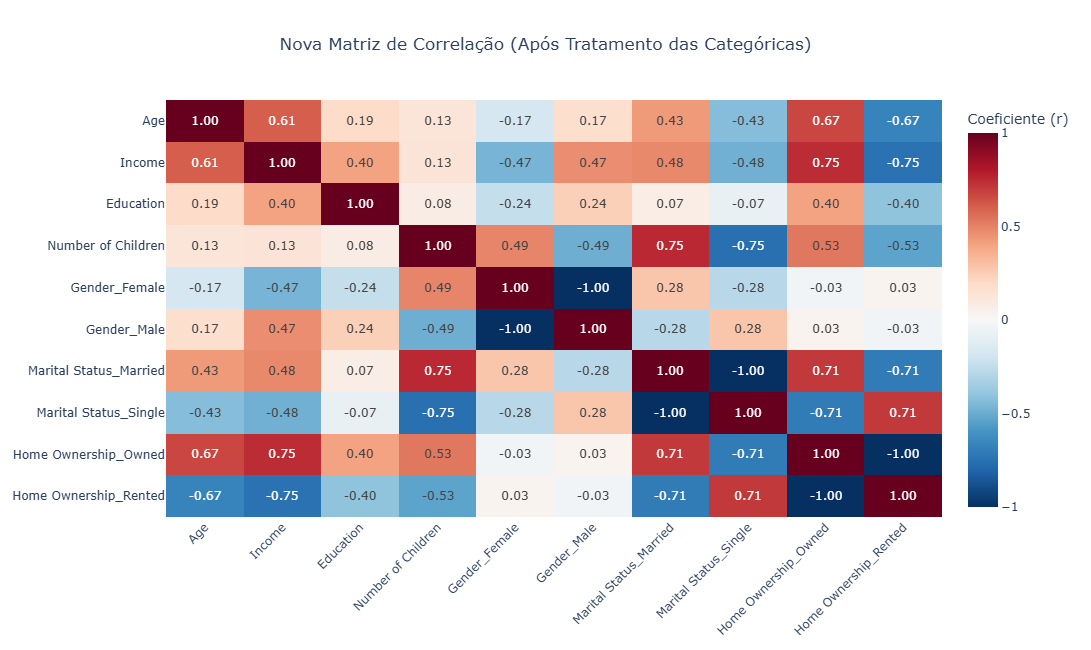

In [230]:
df_numerico = df_final.select_dtypes(include=["number"])
matriz_corr_nova = df_numerico.corr(method="spearman")
fig = px.imshow(
    matriz_corr_nova,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",
    zmin=-1,
    zmax=1,
    title="Nova Matriz de Correlação (Após Tratamento das Categóricas)",
    labels=dict(color="Coeficiente (r)"),
    template="plotly_white",
    aspect="auto",
)
fig.update_traces(
    hovertemplate="<b>Variável X:</b> %{x}<br><b>Variável Y:</b> %{y}<br><b>Correlação:</b> %{z:.2f}<extra></extra>"
)
fig.update_layout(
    height=650,
    width=850,
    title_x=0.5,
    xaxis_tickangle=-45,
)
fig.show()

**F) Faça a separação da base em treino e teste e verifique utilizando shape:**

In [231]:
from sklearn.model_selection import train_test_split

coluna_alvo = "Credit Score"

X = df_final.drop(columns=[coluna_alvo])
y = df_final[coluna_alvo]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"X Total: {X.shape}")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}\n")

print(f"y Total: {y.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")
print(df_final.columns.tolist())

X Total: (164, 10)
X_train: (131, 10)
X_test:  (33, 10)

y Total: (164,)
y_train: (131,)
y_test:  (33,)
['Age', 'Income', 'Education', 'Number of Children', 'Credit Score', 'Gender_Female', 'Gender_Male', 'Marital Status_Married', 'Marital Status_Single', 'Home Ownership_Owned', 'Home Ownership_Rented']


**G) É hora de verificar se nossa coluna de Score de crédito está balanceada, verifique através de um gráfico e traga sua opinião acerca do balanceamento.**

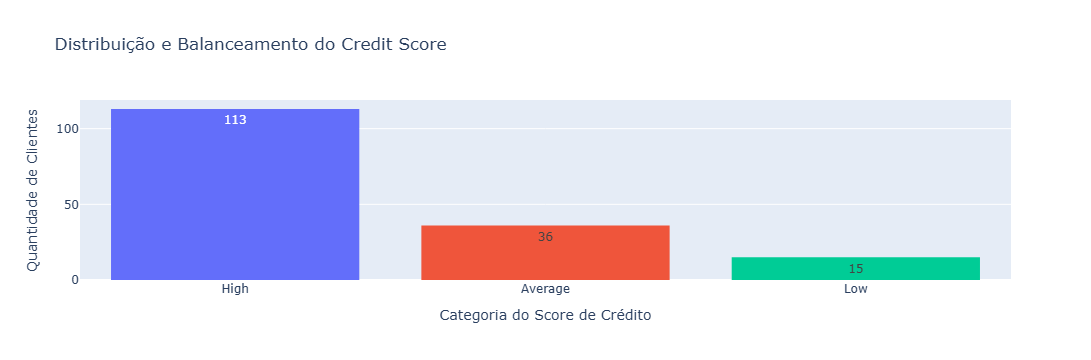

In [232]:
fig = px.histogram(
    df, 
    x="Credit Score", 
    title="Distribuição e Balanceamento do Credit Score",
    labels={"Credit Score": "Score de Crédito", "count": "Quantidade"},
    color="Credit Score",
    text_auto=True
)
fig.update_layout(
    xaxis_title="Categoria do Score de Crédito",
    yaxis_title="Quantidade de Clientes",
    showlegend=False
)
fig.show()

**H) Vamos realizar o balancecamento dos dados da coluna de credit score.**
Se lembre que realizazmos apenas para a base de treino.

In [233]:
X = df_final.drop(columns=["Credit Score"])
y = df_final["Credit Score"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print("Distribuição do y_train antes do balanceamento:")
print(y_train.value_counts())
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
print("\nDistribuição do y_train após o balanceamento:")
print(y_train_balanced.value_counts())

Distribuição do y_train antes do balanceamento:
Credit Score
High       90
Average    29
Low        12
Name: count, dtype: int64

Distribuição do y_train após o balanceamento:
Credit Score
High       90
Low        90
Average    90
Name: count, dtype: int64
